# Inferencing with Pretrained YOLO Models

In [12]:
%pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.43  Python-3.11.9 torch-2.11.0+cpu CPU (11th Gen Intel Core i5-1135G7 @ 2.40GHz)


Setup complete  (4 CPUs, 7.7 GB RAM, 332.6/475.8 GB disk)


Inferencing with YOLOv11 Pretrained Model

In [13]:
import cv2
import matplotlib.pyplot as plt

def show_image(image_path):
    # Load the image using OpenCV
    image = cv2.imread(image_path)
    
    if image is None:
        print("Error: Image not found!")
        return

    # IMPORTANT: OpenCV loads images in BGR format, 
    # but Matplotlib expects RGB. We must convert it.
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Display using Matplotlib
    plt.imshow(image_rgb)
    plt.axis('off') # Hide the x/y axis coordinates
    plt.show()

In [14]:
# Run inference on an image with YOLO11n
!yolo predict model=yolo11s.pt source="https://images.pexels.com/photos/13872248/pexels-photo-13872248.jpeg"

Ultralytics 8.4.43  Python-3.11.9 torch-2.11.0+cpu CPU (11th Gen Intel Core i5-1135G7 @ 2.40GHz)
YOLO11s summary (fused): 100 layers, 9,443,760 parameters, 0 gradients, 21.5 GFLOPs

Found https://images.pexels.com/photos/13872248/pexels-photo-13872248.jpeg locally at pexels-photo-13872248.jpeg
image 1/1 c:\Users\Jagdish singh\DEEP-LEARNING\Object_Detection\pexels-photo-13872248.jpeg: 448x640 6 persons, 575.8ms
Speed: 80.4ms preprocess, 575.8ms inference, 31.1ms postprocess per image at shape (1, 3, 448, 640)
Results saved to C:\Users\Jagdish singh\DEEP-LEARNING\Object_Detection\runs\detect\predict-2
 Learn more at https://docs.ultralytics.com/modes/predict


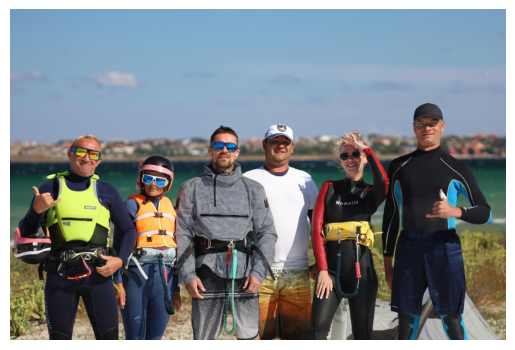

In [15]:
show_image(r'C:\Users\Jagdish singh\DEEP-LEARNING\Object_Detection\pexels-photo-13872248.jpeg')

In [20]:
import cv2
import matplotlib.pyplot as plt
import os

# 1. Run the prediction (if you haven't already)
# !yolo predict model=yolo11s.pt source="https://images.pexels.com/photos/13872248/pexels-photo-13872248.jpeg"

# 2. Path to the saved result (usually the latest 'predict' folder)
# In Lightning AI / VS Code, it will be in your project directory
res_path = 'runs/detect/predict/pexels-photo-13872248.jpeg'

if os.path.exists(res_path):
    img = cv2.imread(res_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()
else:
    print("Check your 'runs' folder to find the correct path!")

Check your 'runs' folder to find the correct path!


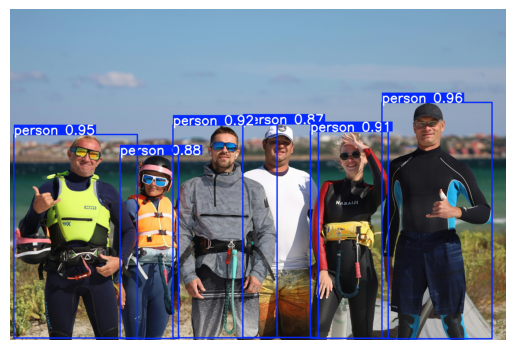

In [21]:
show_image(r'C:\Users\Jagdish singh\DEEP-LEARNING\Object_Detection\runs\detect\predict\pexels-photo-13872248.jpg')

In [16]:
from ultralytics import YOLO

# Load YOLO model
model = YOLO("yolo11s.pt")  # load an official model

In [23]:
model.names

{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou

In [17]:
# Predict with the model
results = model("https://images.pexels.com/photos/13872248/pexels-photo-13872248.jpeg")  # predict on an image


Found https://images.pexels.com/photos/13872248/pexels-photo-13872248.jpeg locally at pexels-photo-13872248.jpeg
image 1/1 c:\Users\Jagdish singh\DEEP-LEARNING\Object_Detection\pexels-photo-13872248.jpeg: 448x640 6 persons, 214.3ms
Speed: 8.4ms preprocess, 214.3ms inference, 2.9ms postprocess per image at shape (1, 3, 448, 640)


In [18]:
# Access the results
for i, result in enumerate(results):
    print(f"\nResult {i + 1}:")

    xywh = result.boxes.xywh  # center-x, center-y, width, height
    print("  Bounding Boxes (xywh):")
    print(xywh)

    xywhn = result.boxes.xywhn  # normalized
    print("  Normalized Bounding Boxes (xywhn):")
    print(xywhn)

    xyxy = result.boxes.xyxy  # top-left-x, top-left-y, bottom-right-x, bottom-right-y
    print("  Bounding Boxes (xyxy):")
    print(xyxy)

    xyxyn = result.boxes.xyxyn  # normalized
    print("  Normalized Bounding Boxes (xyxyn):")
    print(xyxyn)

    names = [result.names[cls.item()] for cls in result.boxes.cls.int()]  # class name of each box
    print("  Class Names:")
    print(names)

    confs = result.boxes.conf  # confidence score of each box
    print("  Confidence Scores:")
    print(confs)


Result 1:
  Bounding Boxes (xywh):
tensor([[5371.8423, 2659.6116, 1385.6064, 2969.8550],
        [ 825.0819, 2856.1040, 1554.0432, 2557.8352],
        [2705.7310, 2794.7075, 1309.7844, 2675.9727],
        [4268.9883, 2838.6821,  978.8481, 2599.6514],
        [1751.7101, 2985.8149,  734.6653, 2309.9873],
        [3404.5625, 2786.0786,  950.6799, 2685.0967]])
  Normalized Bounding Boxes (xywhn):
tensor([[0.8609, 0.6393, 0.2221, 0.7139],
        [0.1322, 0.6866, 0.2490, 0.6149],
        [0.4336, 0.6718, 0.2099, 0.6433],
        [0.6841, 0.6824, 0.1569, 0.6249],
        [0.2807, 0.7177, 0.1177, 0.5553],
        [0.5456, 0.6697, 0.1524, 0.6455]])
  Bounding Boxes (xyxy):
tensor([[4679.0391, 1174.6840, 6064.6455, 4144.5391],
        [  48.0603, 1577.1863, 1602.1035, 4135.0215],
        [2050.8386, 1456.7212, 3360.6230, 4132.6938],
        [3779.5640, 1538.8563, 4758.4121, 4138.5078],
        [1384.3774, 1830.8212, 2119.0427, 4140.8086],
        [2929.2227, 1443.5302, 3879.9026, 4128.6270]])

In [19]:
# Access the results
for i, result in enumerate(results):
    print(f"\nResult {i + 1}:")

    xywh = result.boxes.xywh  # center-x, center-y, width, height
    print("  Bounding Boxes (xywh):")
    print(xywh)

    xywhn = result.boxes.xywhn  # normalized
    print("  Normalized Bounding Boxes (xywhn):")
    print(xywhn)

    xyxy = result.boxes.xyxy  # top-left-x, top-left-y, bottom-right-x, bottom-right-y
    print("  Bounding Boxes (xyxy):")
    print(xyxy)

    xyxyn = result.boxes.xyxyn  # normalized
    print("  Normalized Bounding Boxes (xyxyn):")
    print(xyxyn)

    names = [result.names[cls.item()] for cls in result.boxes.cls.int()]  # class name of each box
    print("  Class Names:")
    print(names)

    confs = result.boxes.conf  # confidence score of each box
    print("  Confidence Scores:")
    print(confs)


Result 1:
  Bounding Boxes (xywh):
tensor([[5371.8423, 2659.6116, 1385.6064, 2969.8550],
        [ 825.0819, 2856.1040, 1554.0432, 2557.8352],
        [2705.7310, 2794.7075, 1309.7844, 2675.9727],
        [4268.9883, 2838.6821,  978.8481, 2599.6514],
        [1751.7101, 2985.8149,  734.6653, 2309.9873],
        [3404.5625, 2786.0786,  950.6799, 2685.0967]])
  Normalized Bounding Boxes (xywhn):
tensor([[0.8609, 0.6393, 0.2221, 0.7139],
        [0.1322, 0.6866, 0.2490, 0.6149],
        [0.4336, 0.6718, 0.2099, 0.6433],
        [0.6841, 0.6824, 0.1569, 0.6249],
        [0.2807, 0.7177, 0.1177, 0.5553],
        [0.5456, 0.6697, 0.1524, 0.6455]])
  Bounding Boxes (xyxy):
tensor([[4679.0391, 1174.6840, 6064.6455, 4144.5391],
        [  48.0603, 1577.1863, 1602.1035, 4135.0215],
        [2050.8386, 1456.7212, 3360.6230, 4132.6938],
        [3779.5640, 1538.8563, 4758.4121, 4138.5078],
        [1384.3774, 1830.8212, 2119.0427, 4140.8086],
        [2929.2227, 1443.5302, 3879.9026, 4128.6270]])